# Resolving CBIS-DDSM DICOM Paths

The CSV `image file path` entries don't always match the directory names. Three folder-naming conventions appear:

1. **Exact match** - the CSV base folder name exists on disk as-is.
2. **Suffix mismatch** - the folder is stored with a different `_N` suffix than the one the CSV records.
3. **Bare patient dir** - only `P_xxxxx_VIEW` exists, without the lesion-type prefix the CSV uses.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

# Project working directory
WORK_DIR = Path.cwd().parent
# Project data directory
DATA_DIR = WORK_DIR / "data"

# Main dataset directory
CBIS_DDSM_DIR = DATA_DIR / "cbis-ddsm"

# DICOM images
# Use relative path to avoid saving my local absolute path in the notebook
DICOM_DIR = Path("../data/cbis-ddsm/cbis_ddsm")

## Inspect Paths

In [2]:
csv_path = CBIS_DDSM_DIR / "mass_case_description_train_set.csv"

df = pd.read_csv(csv_path)
for v in df["image file path"].dropna().head(5):
    print(v)

Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/1-1.dcm
Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.9590.100.1.2.319478999311971442426185353560182990988/1.3.6.1.4.1.9590.100.1.2.359308329312397897125630708681441180834/1-1.dcm
Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.347107867812656628709864319310977895697/1.3.6.1.4.1.9590.100.1.2.89180046211022531834352631483669346540/1-1.dcm
Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.9590.100.1.2.272600286511817402806912403581910920939/1.3.6.1.4.1.9590.100.1.2.295360926313492745441868049270168300162/1-1.dcm
Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.9590.100.1.2.174047308712169195014610267031196524486/1.3.6.1.4.1.9590.100.1.2.410524754913057908920631336070876889890/1-1.dcm


## DICOMPathResolver

Helper class to resolve and map the correct DICOM paths

In [3]:
from src.data.cbis_ddsm import DICOMPathResolver

resolver = DICOMPathResolver(DICOM_DIR)

## Inspect one row

In [4]:
row = df.iloc[0]
print(f"Resolving paths for row:\n{row}\n")

full_img, crop_img, mask_img = resolver.resolve_case(
    row["image file path"],
    row["cropped image file path"],
    row["ROI mask file path"]
)

print(f"Full image: {full_img}")
print(f"Crop image: {crop_img}")
print(f"Mask image: {mask_img}")

Resolving paths for row:
patient_id                                                           P_00001
breast_density                                                             3
left or right breast                                                    LEFT
image view                                                                CC
abnormality id                                                             1
abnormality type                                                        mass
mass shape                                IRREGULAR-ARCHITECTURAL_DISTORTION
mass margins                                                      SPICULATED
assessment                                                                 4
pathology                                                          MALIGNANT
subtlety                                                                   4
image file path            Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...
cropped image file path    Mass-Training_P_00001_LE

## Resolving the full dataset

In [5]:
df_resolved = resolver.resolve_dataframe(df.copy())

total_count = len(df_resolved)
found_count = df_resolved["full_image_path"].notna().sum()
missing_count = total_count - found_count

print(f"Total row: {total_count}")
print(f"Resolved rows: {found_count}")
print(f"Missing rows: {missing_count}")

display(df_resolved[["image file path", "full_image_path", "cropped_path", "roi_mask_path"]].head(5))

Total row: 1318
Resolved rows: 1318
Missing rows: 0


,image file path,full_image_path,cropped_path,roi_mask_path
0,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,../data/cbis-ddsm/cbis_ddsm/Mass-Training_P_00...,../data/cbis-ddsm/cbis_ddsm/Mass-Training_P_00...,../data/cbis-ddsm/cbis_ddsm/Mass-Training_P_00...
1,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,../data/cbis-ddsm/cbis_ddsm/Mass-Training_P_00...,../data/cbis-ddsm/cbis_ddsm/Mass-Training_P_00...,../data/cbis-ddsm/cbis_ddsm/Mass-Training_P_00...
2,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,../data/cbis-ddsm/cbis_ddsm/Mass-Training_P_00...,../data/cbis-ddsm/cbis_ddsm/Mass-Training_P_00...,../data/cbis-ddsm/cbis_ddsm/Mass-Training_P_00...
3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,../data/cbis-ddsm/cbis_ddsm/Mass-Training_P_00...,../data/cbis-ddsm/cbis_ddsm/Mass-Training_P_00...,../data/cbis-ddsm/cbis_ddsm/Mass-Training_P_00...
4,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,../data/cbis-ddsm/cbis_ddsm/Mass-Training_P_00...,../data/cbis-ddsm/cbis_ddsm/Mass-Training_P_00...,../data/cbis-ddsm/cbis_ddsm/Mass-Training_P_00...


## Crop vs. Mask Disambiguation

The resolver identifies both cropped patch and ROI mask within the same parent folder by pixel area:
- Smaller file is the crop
- Larger file is the mask

In [6]:
import pydicom

samples = df_resolved.head(3)
for _, row in samples.iterrows():
    cropped = pydicom.dcmread(row["cropped_path"])
    roi = pydicom.dcmread(row["roi_mask_path"])

    cropped_area = int(cropped.Rows * cropped.Columns)
    roi_area = int(roi.Rows * roi.Columns)

    print(f"Crop vs ROI area: {cropped_area:,} < {roi_area:,}")

Crop vs ROI area: 221,965 < 14,539,392
Crop vs ROI area: 74,752 < 12,748,800
Crop vs ROI area: 197,118 < 16,396,126


## Sample Preview

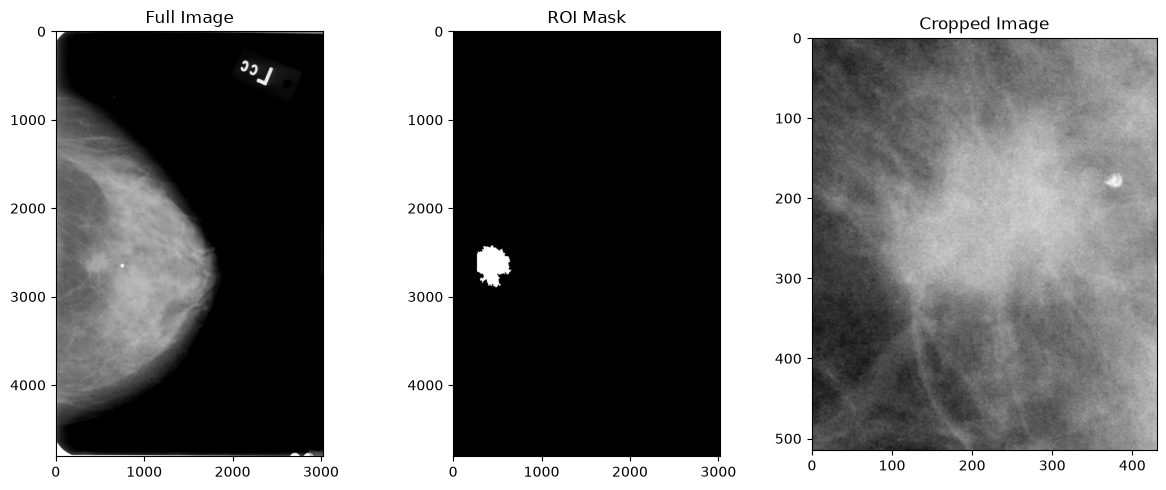

In [7]:
sample = samples.iloc[0]

fig, ax = plt.subplots(1, 3, figsize=(12, 5))

full_img = pydicom.dcmread(sample["full_image_path"])
cropped = pydicom.dcmread(sample["cropped_path"])
roi = pydicom.dcmread(sample["roi_mask_path"])

ax[0].imshow(full_img.pixel_array, cmap="gray")
ax[0].set_title("Full Image")
ax[1].imshow(roi.pixel_array, cmap="gray")
ax[1].set_title("ROI Mask")
ax[2].imshow(cropped.pixel_array, cmap="gray")
ax[2].set_title("Cropped Image")

plt.tight_layout()
plt.show()